In [1]:
# -*- coding: utf-8 -*-
"""
modalanalysis_owt
----------

Driver for Modal analysis of beam/Frame structure.

Created: June 2020

@author: Oscar Bondo Ellekvist, s163774
         Modified spring 2026 for owt case with ship impact
     
"""

# Import packages
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys

# Import functions
from timestep import timestep
from scipy import linalg as linalg

### INPUT
npzfile = np.load('owt_XKM.npz')
X   = npzfile['X']
K   = npzfile['K']
M   = npzfile['M']

### NODES and GEOMETRY
# Dimensions of 3D FE model = 6 dofs per node: 
# [disp_x disp_y disp_z rot_x rot_y rot_z] in global {x,y,z}-coord sys.
dof  = 6
ndof = np.size(X,1)*dof
print(ndof)

# eigenvalue problem
n_modes = 50
[lam,U] = sp.linalg.eigh(K, M, subset_by_index=[0, n_modes - 1])
lam = np.real(lam)
omega = np.sqrt(lam)
iw = np.argsort(omega)

omega = omega[iw]
freq  = omega/(2*np.pi)
U = U[:,iw]
U = U / U[np.argmax(np.abs(U), axis=0), np.arange(0, n_modes)]

1674


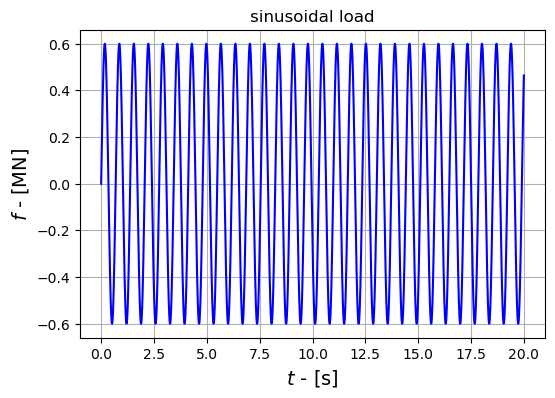

In [2]:
# Initial conditions
x0 = np.zeros((ndof,1),dtype=float)
v0 = x0

# Damping ratio (constant modal damping) for all modes included
zeta = 0.025

# Time simulation parameters
t0 = 0                  # initial time
N  = 20000              # number of time steps
dt = 0.001              # time step size

# Load vector - sine at node 50 in y-direction
nodef = 50
tf = np.arange(0,N+1,1,dtype=float)*dt   # time vector
omegaf = omega[12] # natural angular frequency of mode 13 in rad/s
freqf = freq[12] # frequency of mode 13
Tf = 1/freqf
F_sinusoidal = np.zeros((ndof,N+1),dtype=float)
F_sinusoidal[(nodef-1)*6+2-1,:] = 0.6e6*np.sin(omegaf*tf)

# plot force
fig10 = plt.figure(10,figsize=[6,4])
plt.plot(tf,F_sinusoidal[(nodef-1)*6+2-1,:]*1e-6,color='blue')
plt.title('sinusoidal load')
plt.xlabel(r'$t$ - [s]', fontsize=14)
plt.ylabel(r'$f$ - [MN]', fontsize=14)
plt.grid()
plt.show()


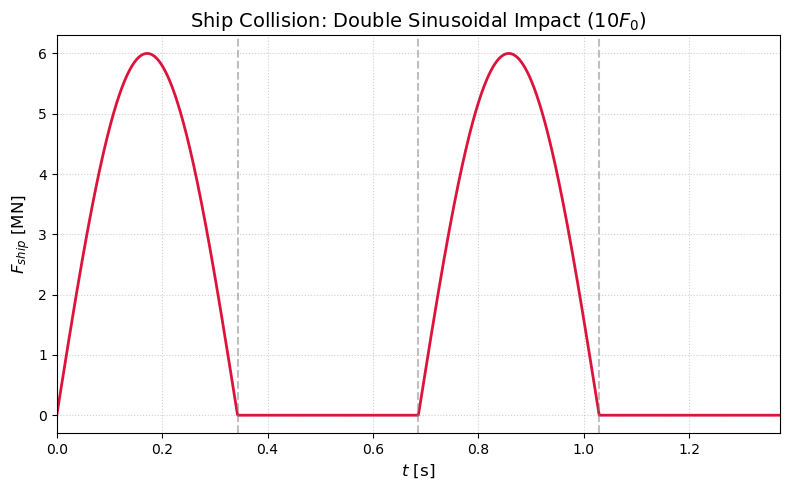

In [3]:
### SHIP COLLISION LOAD (DOUBLE IMPACT)

# 1. Constants from Equation 8
nodef = 50                 # Impact node
F0 = 0.6e6                 # Base force 0.6 MN in Newtons
omegaf = omega[12]         # Forcing frequency = Mode 13 frequency
Tf = 2 * np.pi / omegaf    # Forcing period

# 2. Initialize Force Matrix (ndof x time_steps)
F_ship = np.zeros((ndof, N + 1), dtype=float)

# 3. Define the piecewise time intervals (Boolean Masks)
# Pulse 1: 0 <= t <= 0.5 * Tf
mask1 = (tf >= 0) & (tf <= 0.5 * Tf)

# Pulse 2: Tf <= t <= 1.5 * Tf
mask2 = (tf >= Tf) & (tf <= 1.5 * Tf)

# 4. Calculate Force Magnitude
# We apply the formula: 10 * F0 * sin(pi * (t_relative) / (0.5 * Tf))
# Target DOF: Node 50, y-direction -> (50-1)*6 + 1
target_dof = (nodef - 1) * 6 + 1

# First Impact
F_ship[target_dof, mask1] = 10 * F0 * np.sin(np.pi * tf[mask1] / (0.5 * Tf))

# Second Impact (shifted by Tf)
F_ship[target_dof, mask2] = 10 * F0 * np.sin(np.pi * (tf[mask2] - Tf) / (0.5 * Tf))

# 5. Plot the loading record
fig10 = plt.figure(10, figsize=[8, 5])
plt.plot(tf, F_ship[target_dof, :] * 1e-6, color='crimson', lw=2)

# Visualizing the pulse limits for clarity
plt.axvline(0.5 * Tf, color='gray', linestyle='--', alpha=0.5)
plt.axvline(Tf, color='gray', linestyle='--', alpha=0.5)
plt.axvline(1.5 * Tf, color='gray', linestyle='--', alpha=0.5)

plt.title('Ship Collision: Double Sinusoidal Impact ($10F_0$)', fontsize=14)
plt.xlabel(r'$t$ [s]', fontsize=12)
plt.ylabel(r'$F_{ship}$ [MN]', fontsize=12)
plt.xlim([0, 2 * Tf]) # Zoom in on the impact events
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
### MODAL ANALYSIS

# Modal mass and stiffness
mm = np.linalg.multi_dot((np.transpose(U),M,U))
km = np.linalg.multi_dot((np.transpose(U),K,U))

# Initial conditions
r0 = np.linalg.solve(mm,np.linalg.multi_dot((np.transpose(U),M,x0)))
dr0 = np.linalg.solve(mm,np.linalg.multi_dot((np.transpose(U),M,v0)))

# Modal load
f = np.dot(np.transpose(U),F_ship)
    

In [5]:
### 1. COMPUTE RESPONSES (WITH VELOCITY FOR ENERGY)
# Initialize storage
r_sin = np.zeros((n_modes, N+1))
dr_sin = np.zeros((n_modes, N+1))   # Added this
ddr_sin = np.zeros((n_modes, N+1))

r_imp = np.zeros((n_modes, N+1))
dr_imp = np.zeros((n_modes, N+1))   # Added this
ddr_imp = np.zeros((n_modes, N+1))

# Project global force to modal force
fj_sin_all = np.dot(U[:, :n_modes].T, F_sinusoidal)
fj_imp_all = np.dot(U[:, :n_modes].T, F_ship)

for j in range(n_modes):
    mj, kj = mm[j,j], km[j,j]
    cj = 2 * zeta * np.sqrt(mj * kj)
    
    # Solve Case 1: Sinusoidal
    # timestep returns: (displacement, velocity, acceleration, _, time)
    rj_s, drj_s, ddrj_s, _, _ = timestep(mj, cj, kj, 0, 0, t0, dt, N, fj_sin_all[j,:])
    r_sin[j,:] = rj_s
    dr_sin[j,:] = drj_s
    ddr_sin[j,:] = ddrj_s
    
    # Solve Case 2: Double Impact
    rj_i, drj_i, ddrj_i, _, _ = timestep(mj, cj, kj, 0, 0, t0, dt, N, fj_imp_all[j,:])
    r_imp[j,:] = rj_i
    dr_imp[j,:] = drj_i
    ddr_imp[j,:] = ddrj_i
    

In [6]:
# --- PHYSICAL RESPONSE RECONSTRUCTION ---
# Choose which degree of freedom (node) you want to plot (e.g., the first one [0])
node_idx = (41-1)*6 + 1

# Reconstruct physical displacement: q = U * r
# Reconstruct physical acceleration: a = U * ddr
q_sin_plot = np.dot(U[node_idx, :n_modes], r_sin)
a_sin_plot = np.dot(U[node_idx, :n_modes], ddr_sin)

q_imp_plot = np.dot(U[node_idx, :n_modes], r_imp)
a_imp_plot = np.dot(U[node_idx, :n_modes], ddr_imp)

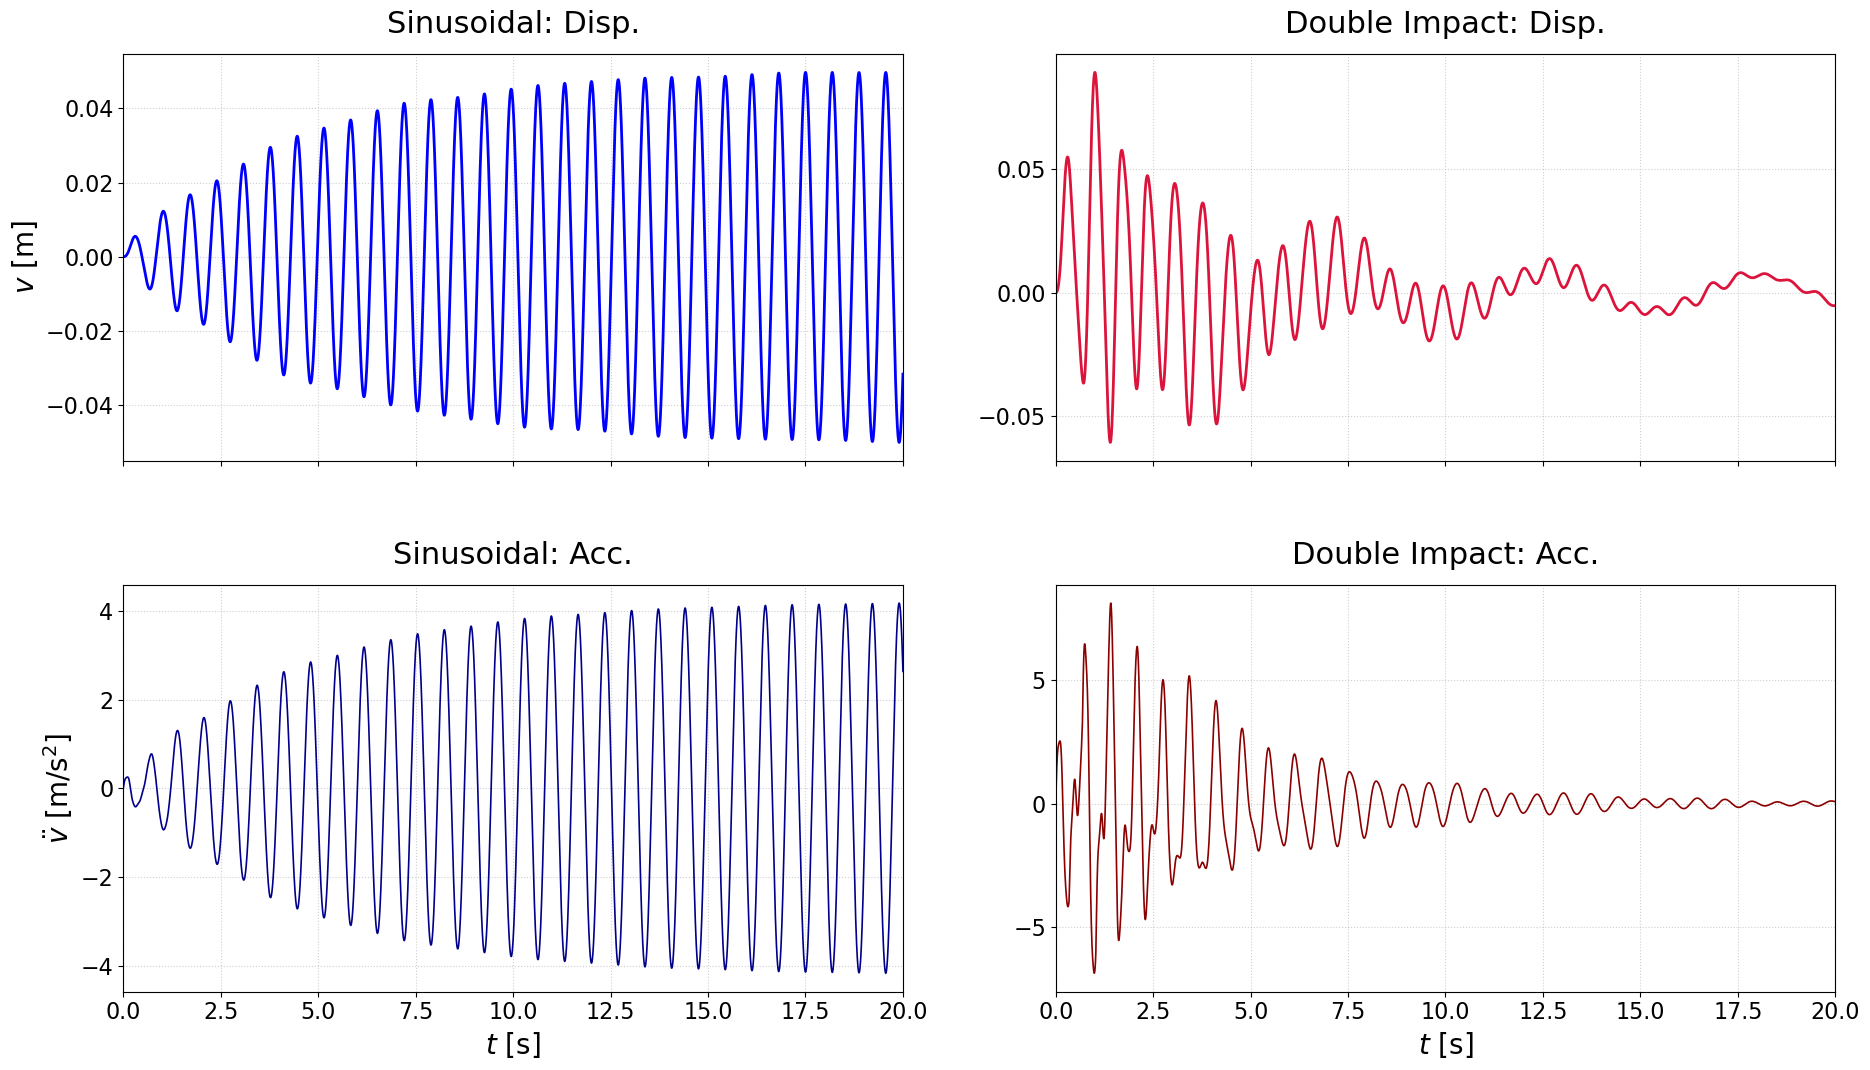

In [7]:
### 2. PLOTTING WITH ENLARGED FONTS
plt.close('all')

# Update global parameters for large, readable text
plt.rcParams.update({
    'font.size': 18,          # Base font size
    'axes.titlesize': 22,     # Title size
    'axes.labelsize': 20,     # X and Y label size
    'xtick.labelsize': 16,    # X-axis tick size
    'ytick.labelsize': 16,    # Y-axis tick size
    'legend.fontsize': 16     # Legend size
})

fig, ax = plt.subplots(2, 2, figsize=[20, 12], sharex=True)

# --- DISPLACEMENT PLOTS (Top Row) ---
# Sinusoidal
ax[0, 0].plot(tf, q_sin_plot, color='blue', lw=2)
ax[0, 0].set_title(f'Sinusoidal: Disp.', pad=15)
ax[0, 0].set_ylabel(r'$v$ [m]')

# Double Impact
ax[0, 1].plot(tf, q_imp_plot, color='crimson', lw=2)
ax[0, 1].set_title(f'Double Impact: Disp.', pad=15)

# --- ACCELERATION PLOTS (Bottom Row) ---
# Sinusoidal
ax[1, 0].plot(tf, a_sin_plot, color='darkblue', lw=1.2)
ax[1, 0].set_title(f'Sinusoidal: Acc.', pad=15)
ax[1, 0].set_ylabel(r'$\ddot{v}$ [m/s$^2$]')
ax[1, 0].set_xlabel(r'$t$ [s]')

# Double Impact
ax[1, 1].plot(tf, a_imp_plot, color='darkred', lw=1.2)
ax[1, 1].set_title(f'Double Impact: Acc.', pad=15)
ax[1, 1].set_xlabel(r'$t$ [s]')

# Apply common formatting to all subplots
for a in ax.flat:
    a.grid(True, linestyle=':', alpha=0.6)
    a.set_xlim([0, 20])
    # Ensure y-axis doesn't have too many labels to keep it clean
    a.locator_params(axis='y', nbins=6)

plt.tight_layout(pad=3.0) # Add padding to prevent titles/labels overlapping
plt.show()

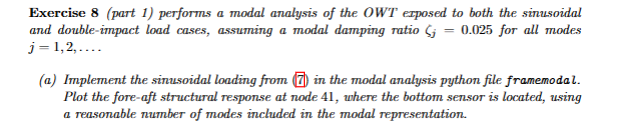

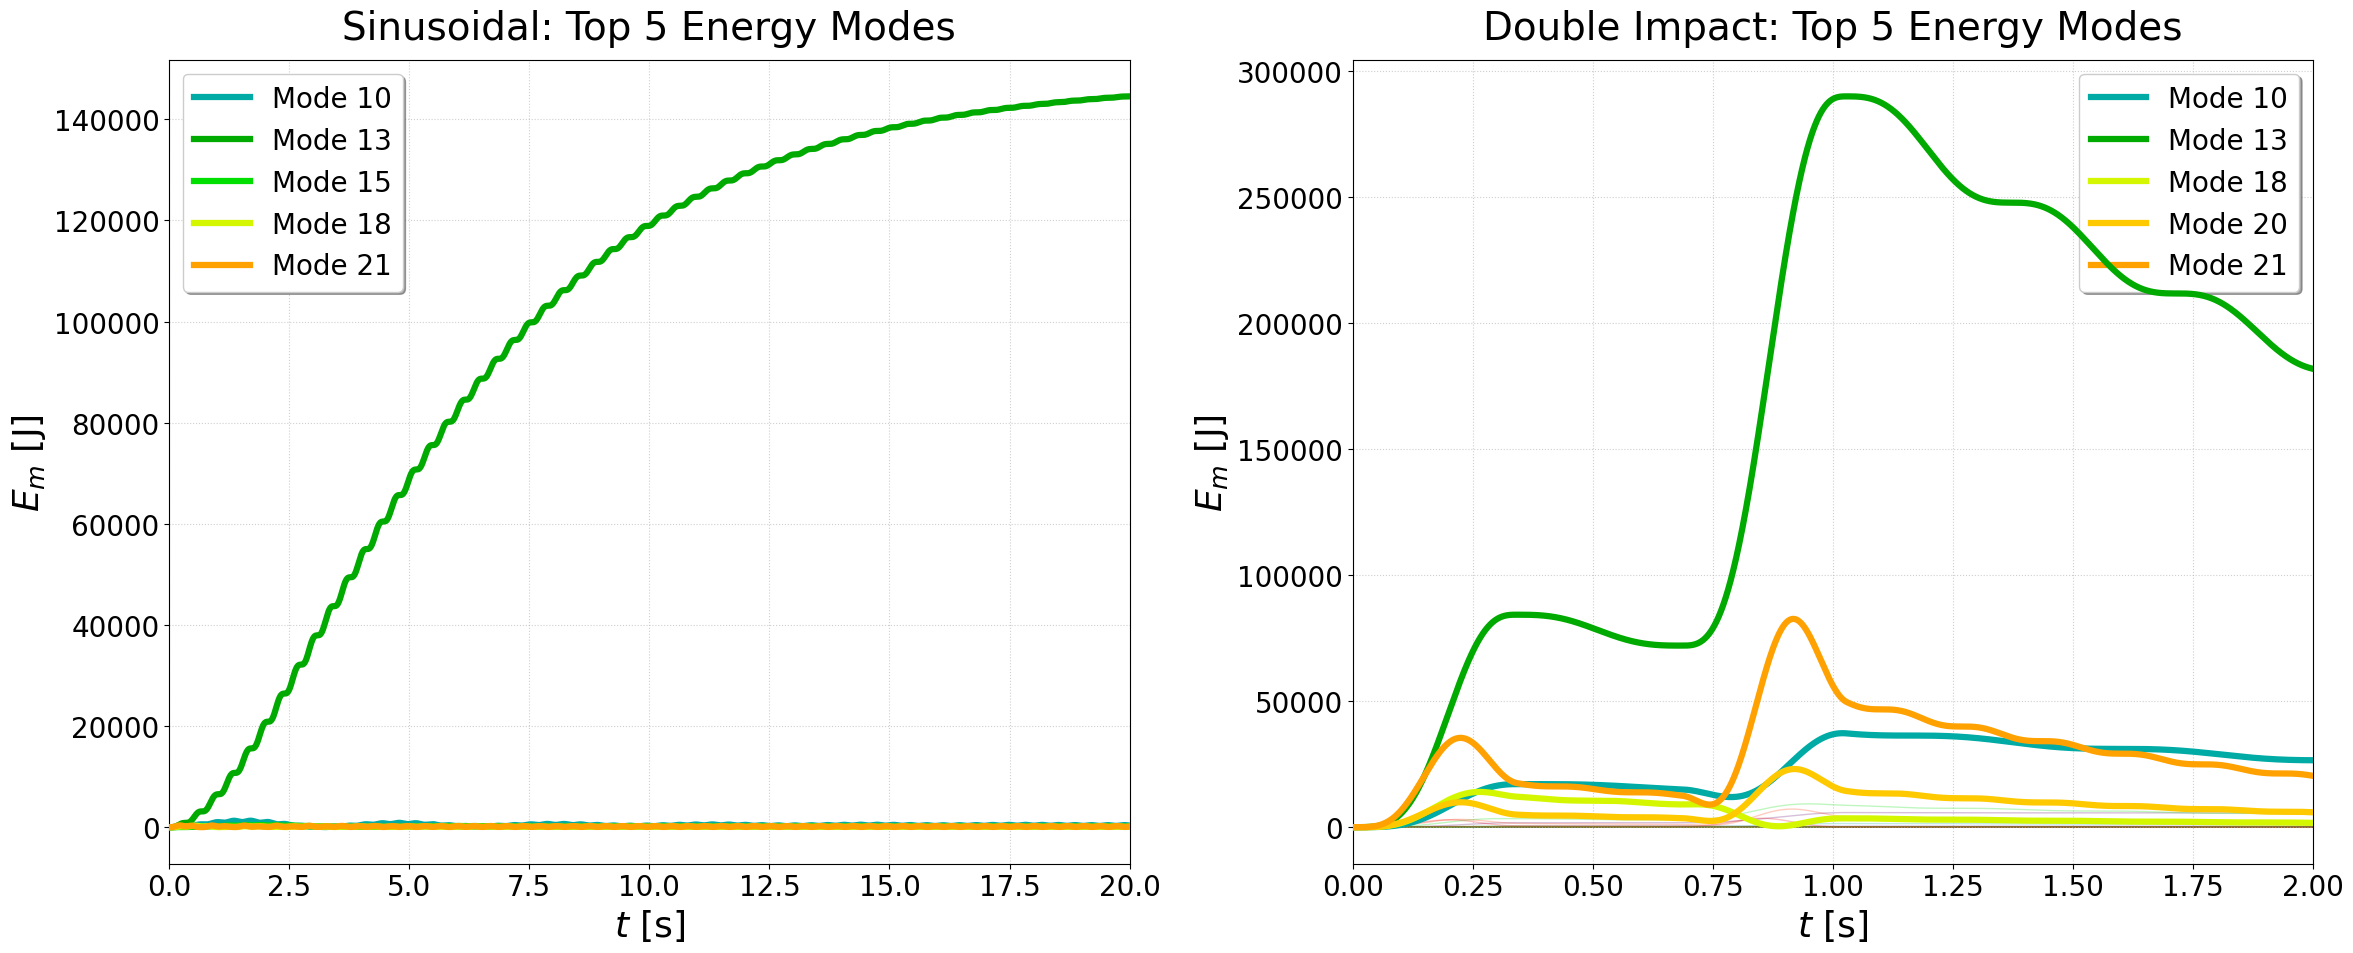

In [8]:
### 1. PRE-CALCULATE ENERGY MATRICES
Em_sin = np.zeros((n_modes, N+1))
Em_imp = np.zeros((n_modes, N+1))

for j in range(n_modes):
    mj, kj = mm[j,j], km[j,j]
    Em_sin[j, :] = 0.5 * mj * dr_sin[j, :]**2 + 0.5 * kj * r_sin[j, :]**2
    Em_imp[j, :] = 0.5 * mj * dr_imp[j, :]**2 + 0.5 * kj * r_imp[j, :]**2

### 2. PLOT: MODAL ENERGY WITH TOP 5 HIGHLIGHTS
plt.close('all')

n_plot = 25  
# Using 'nipy_spectral' or 'gist_rainbow' provides maximum color separation
colors_25 = plt.cm.nipy_spectral(np.linspace(0, 0.95, n_plot))

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 26,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[24, 10])

# --- CASE 1: SINUSOIDAL (0 to 20s) ---
t_mask_sin = tf <= 20
peak_energies_sin = np.max(Em_sin[:n_plot, t_mask_sin], axis=1)
top_5_sin = np.argsort(peak_energies_sin)[-5:]

for j in range(n_plot):
    energy = Em_sin[j, :]
    is_top = j in top_5_sin
    lbl = f'Mode {j+1}' if is_top else None
    lw = 4.5 if is_top else 1.0 # Thicker lines for top modes
    alpha = 1.0 if is_top else 0.25 # More transparent background modes
    zorder = 10 if is_top else 1 
    
    ax1.plot(tf, energy, color=colors_25[j], label=lbl, lw=lw, alpha=alpha, zorder=zorder)

ax1.set_title('Sinusoidal: Top 5 Energy Modes', pad=15)
ax1.set_xlabel(r'$t$ [s]')
ax1.set_ylabel(r'$E_{m}$ [J]')
ax1.set_xlim([0, 20])
ax1.legend(loc='upper left', frameon=True, shadow=True, ncol=1)
ax1.grid(True, linestyle=':', alpha=0.6)


# --- CASE 2: DOUBLE IMPACT (0 to 2s) ---
t_mask_imp = tf <= 2
peak_energies_imp = np.max(Em_imp[:n_plot, t_mask_imp], axis=1)
top_5_imp = np.argsort(peak_energies_imp)[-5:]

for j in range(n_plot):
    energy = Em_imp[j, :]
    is_top = j in top_5_imp
    lbl = f'Mode {j+1}' if is_top else None
    lw = 4.5 if is_top else 1.0
    alpha = 1.0 if is_top else 0.25
    zorder = 10 if is_top else 1
    
    ax2.plot(tf, energy, color=colors_25[j], label=lbl, lw=lw, alpha=alpha, zorder=zorder)

ax2.set_title('Double Impact: Top 5 Energy Modes', pad=15)
ax2.set_xlabel(r'$t$ [s]')
ax2.set_ylabel(r'$E_{m}$ [J]')
ax2.set_xlim([0, 2])
ax2.legend(loc='upper right', frameon=True, shadow=True, ncol=1)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
Em = Em_imp

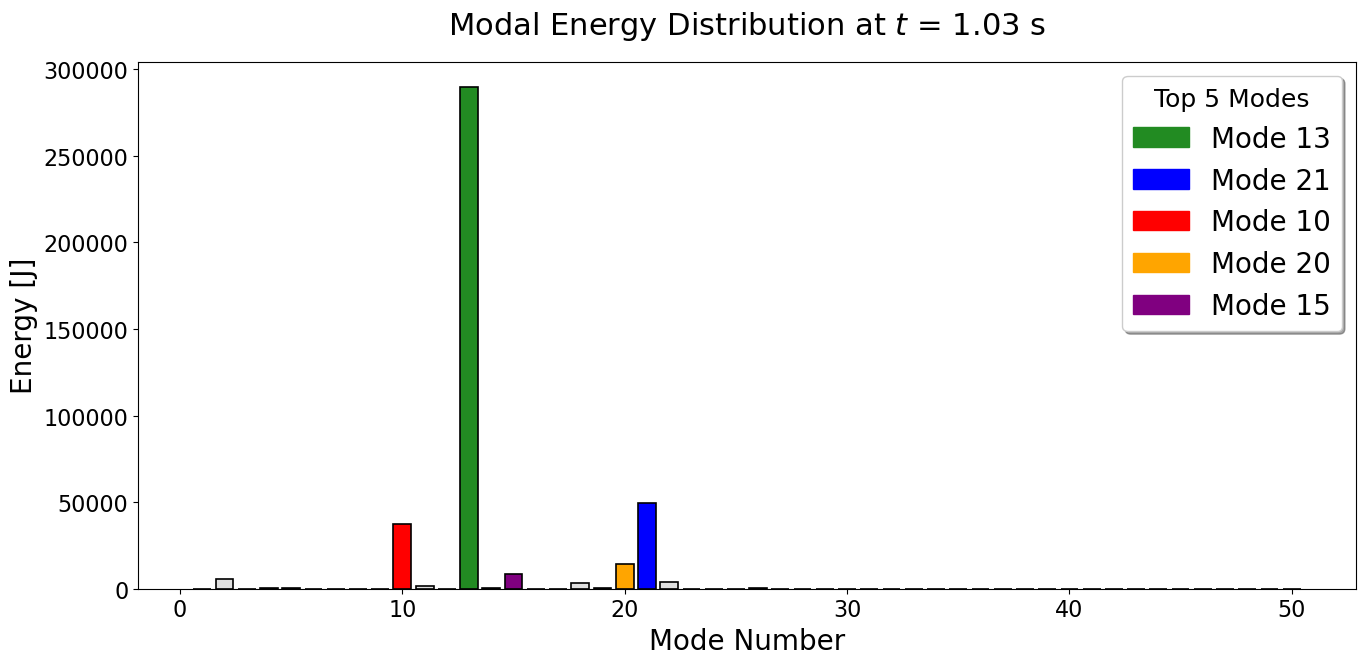

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Update global parameters for the large, readable text you liked
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

# 2. Define target time and find index
# (Ensure tf and omegaf are defined in your workspace)
target_time = 3/2 * 2 * np.pi / omegaf
t_idx = np.argmin(np.abs(tf - target_time))
current_time_actual = tf[t_idx]

# 3. Extract energy and rank top 5
energy_at_t = Em[:, t_idx]
n_modes = len(energy_at_t)
modes = np.arange(1, n_modes + 1)

# Get indices of the 5 largest values (descending)
top_5_idx = np.argsort(energy_at_t)[-5:][::-1]

import matplotlib.patches as mpatches # Import this for the legend handles

# ... (Previous code for t_idx and energy_at_t calculation) ...

# 4. Color Logic
colors = ['#E0E0E0'] * n_modes 
highlight_colors = ['#228B22', '#0000FF', '#FF0000', '#FFA500', '#800080']

# Create a list to store legend handles
legend_handles = []

for i, idx in enumerate(top_5_idx):
    if i < len(highlight_colors):
        color = highlight_colors[i]
        colors[idx] = color
        
        # Create a legend entry for each of the top 5
        # Mode number is idx + 1
        patch = mpatches.Patch(color=color, label=f'Mode {idx + 1}')
        legend_handles.append(patch)

# 5. The Plot
plt.figure(figsize=(14, 7))
plt.bar(modes, energy_at_t, color=colors, edgecolor='black', linewidth=1.2)

# Formatting
plt.title(f'Modal Energy Distribution at $t$ = {current_time_actual:.2f} s', pad=20)
plt.xlabel('Mode Number')
plt.ylabel('Energy [J]')

# ADD THE LEGEND
# We pass the legend_handles we created to the legend function
plt.legend(handles=legend_handles, title="Top 5 Modes", loc='upper right', frameon=True, shadow=True)

# ... (Rest of your formatting: xticks, grid, limits) ...

plt.tight_layout()
plt.show()

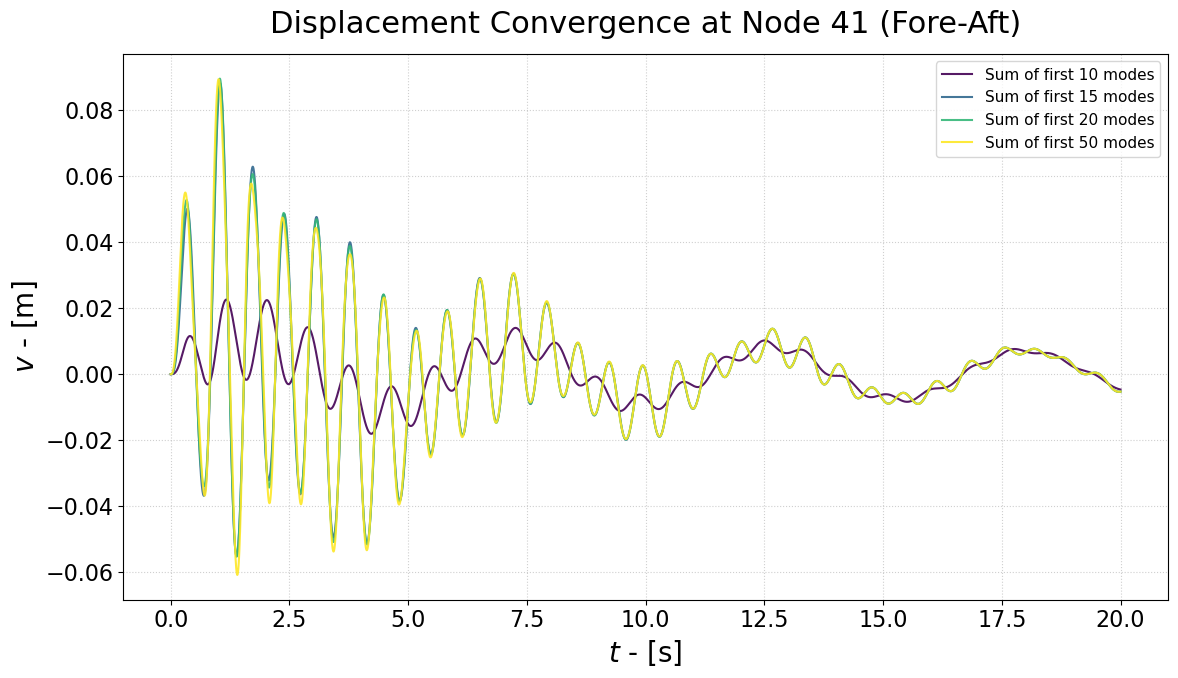

In [11]:
### MODAL CONVERGENCE: DISPLACEMENT USING N MODES
plt.close('all')

# 1. Settings
target_node = 41         # Change to 1 if needed, but 41 or 65 shows more motion
dof_dir = 2              # 2 = Y-direction (Fore-Aft)
# Define the number of modes to include in each line (e.g., 1, 2, 13, 50)
modes_to_include = [10, 15, 20, 50] 

# 2. Setup Plot
plt.figure(figsize=[12, 7])
plt.rcParams.update({'font.size': 14})
colors = plt.cm.viridis(np.linspace(0, 1, len(modes_to_include)))

# Calculate the specific DOF index once
# (Node-1)*6 + Dir - 1
target_dof = (target_node - 1) * 6 + dof_dir - 1

# 3. Loop through the mode counts
for i, n_count in enumerate(modes_to_include):
    
    # Calculate partial displacement: q = U[:, :n] * r[:n, :]
    # This only uses the first 'n_count' modes
    q_partial = np.dot(U[:, :n_count], r_imp[:n_count, :])
    
    # Extract the displacement for our specific node/DOF
    disp_history = q_partial[target_dof, :]
    
    plt.plot(tf, disp_history, 
             color=colors[i], 
             label=f'Sum of first {n_count} modes', 
             linewidth=1.5, 
             alpha=0.9)

# 4. Formatting
plt.title(f'Displacement Convergence at Node {target_node} (Fore-Aft)', pad=15)
plt.xlabel(r'$t$ - [s]')
plt.ylabel(r'$v$ - [m]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

# Optional: Zoom in on the impact window to see the "ripples" from Mode 13
# plt.xlim([0, 2]) 

plt.tight_layout()
plt.show()

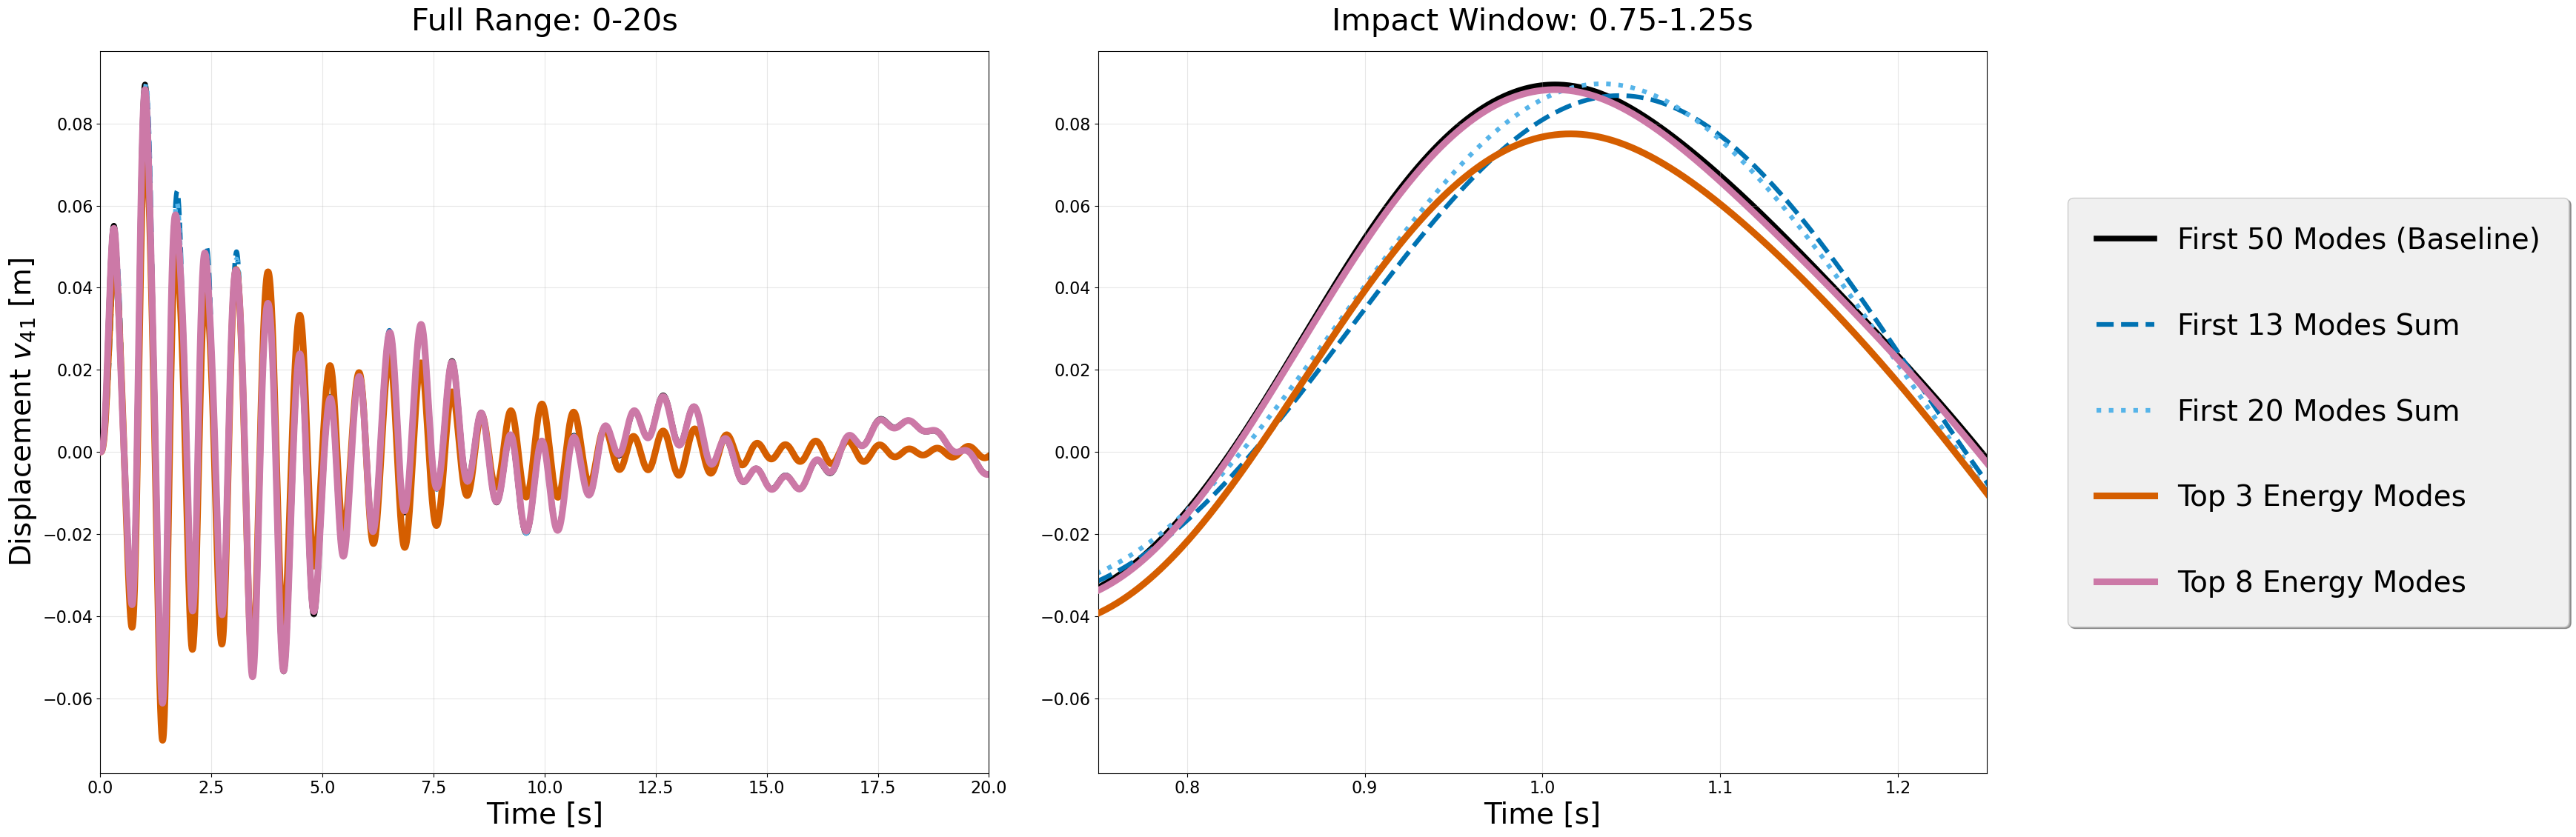

In [23]:
import matplotlib.pyplot as plt
import numpy as np

### MODAL CONVERGENCE ANALYSIS: EXTERNAL LEGEND & UNIQUE COLORS
plt.close('all')

# ==========================================
# SETTINGS: CHOOSE YOUR TIMES HERE
# ==========================================
t_range_1 = [0, 20] 
t_range_2 = [0.75, 1.25]  

target_node = 41
dof_dir = 2 

modes_to_include = [13, 20] 
top_sets = [3, 8]           
# ==========================================

# 1. Identify Energy-based Ranking
t_idx_ref = np.argmin(np.abs(tf - 1.5))
energy_at_ref = Em_imp[:, t_idx_ref]
ranked_idx = np.argsort(energy_at_ref)[::-1]

# 2. Styling Parameters
target_dof = (target_node - 1) * 6 + dof_dir - 1
plt.rcParams.update({
    'font.size': 30, 
    'axes.titlesize': 30, 
    'axes.labelsize': 28,
    'legend.fontsize': 28
})

# Define a palette of unique colors
# [Baseline, Consec1, Consec2, TopSet1, TopSet2]
unique_colors = ['#000000', '#0072B2', '#56B4E9', '#D55E00', '#CC79A7']

# Create 1x3 Subplot (3rd column is for the legend)
fig, (ax1, ax2, ax_leg) = plt.subplots(1, 3, figsize=[36, 12], 
                                     gridspec_kw={'width_ratios': [1, 1, 0.5]})

def plot_convergence(ax, t_range):
    """Helper to plot data. Returns handles for the legend."""
    lines = []
    
    # A. Baseline (Black)
    q_50 = U[target_dof, :50] @ r_imp[:50, :]
    l1, = ax.plot(tf, q_50, color=unique_colors[0], label='First 50 Modes (Baseline)', 
                  lw=5.5, zorder=1)
    lines.append(l1)

    # B. Consecutive Sums (Blues)
    for i, n in enumerate(modes_to_include):
        q_n = U[target_dof, :n] @ r_imp[:n, :]
        ls = '--' if i == 0 else ':'
        l, = ax.plot(tf, q_n, color=unique_colors[i+1], label=f'First {n} Modes Sum', 
                     lw=4.5, ls=ls, zorder=2)
        lines.append(l)

    # C. Top Energetic Subsets (Orange/Pink)
    for i, n in enumerate(top_sets):
        idx = ranked_idx[:n]
        q_top = U[target_dof, idx] @ r_imp[idx, :]
        l, = ax.plot(tf, q_top, color=unique_colors[i+3], label=f'Top {n} Energy Modes', 
                     lw=6.5, zorder=3)
        lines.append(l)

    # Formatting
    ax.set_xlabel('Time [s]')
    ax.set_xlim(t_range) 
    ax.grid(True, linestyle='-', alpha=0.3)
    return lines

# --- EXECUTE PLOTTING ---

# Plot on both axes
plot_convergence(ax1, t_range_1)
handles = plot_convergence(ax2, t_range_2)

# Titles and Labels
ax1.set_title(f'Full Range: {t_range_1[0]}-{t_range_1[1]}s', pad=20)
ax1.set_ylabel('Displacement $v_{41}$ [m]')
ax2.set_title(f'Impact Window: {t_range_2[0]}-{t_range_2[1]}s', pad=20)

# --- SETUP LEGEND WINDOW ---
ax_leg.axis('off') # Hide the axes for the legend window
ax_leg.legend(handles=handles, loc='center', ncol=1, frameon=True, 
              shadow=True, facecolor='#F0F0F0', borderpad=1, labelspacing=2)

plt.tight_layout()
plt.show()